# 🎙️ Speech Emotion Recognition v2 — Emotion-Pretrained Backbone + Focal Loss + Targeted Data Fixes

Fine-tunes a **speech-emotion-pretrained HuBERT** model to classify audio into **7 emotions**:
`angry, disgust, fear, happy, neutral, sad, surprise`

**What's different from v1 (this is the imbalance-aware version):**
1. **Backbone**: `superb/hubert-large-superb-er` — already fine-tuned for emotion on IEMOCAP, instead of generic `wav2vec2-base`. Needs less data per class to reach good minority-class recall, since it starts from emotion-discriminative features rather than raw speech features.
2. **Loss**: custom **Focal Loss** instead of plain cross-entropy — down-weights easy majority-class examples so gradient focuses on hard/minority examples (surprise especially), without touching the data distribution.
3. **Targeted data top-up**: pulls **surprise-only clips from MELD** (Kaggle, freely available, no license wall like IEMOCAP/MSP-Podcast) to directly address the fact that CREMA-D — our largest source — has zero surprise samples.
4. **Targeted augmentation**: `audiomentations`-based pitch/time/noise/gain augmentation applied **only** to under-represented classes in the training set, and only up to a capped multiplier — not blanket oversampling.
5. **Unique run naming**: every run gets a timestamped, descriptive name (e.g. `hubertSER_focal_meldtopup_20260816_1420`) so saved models in Drive never collide or get confused with earlier experiments.

> ⚠️ Runtime: Runtime → Change runtime type → **GPU (T4 or better)**.


## 1. Install dependencies

In [1]:
!pip install -q transformers datasets evaluate accelerate torchaudio librosa soundfile kaggle scikit-learn audiomentations


## 2. Kaggle API setup

Get your `kaggle.json` from https://www.kaggle.com/settings → **Create New Token**, then upload it below.


In [2]:
from google.colab import files
import os

print("Upload your kaggle.json file (from https://www.kaggle.com/settings)")
uploaded = files.upload()  # upload kaggle.json

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured.")


Upload your kaggle.json file (from https://www.kaggle.com/settings)


Saving kaggle.json to kaggle (1).json
Kaggle API configured.


## 3. Download datasets from Kaggle

Base 4 datasets (same as v1) + **MELD**, used later ONLY for its surprise-labeled clips to plug the biggest gap in our label distribution.

| Dataset | Kaggle handle | Purpose |
|---|---|---|
| RAVDESS | `uwrfkaggler/ravdess-emotional-speech-audio` | Base training data |
| CREMA-D | `ejlok1/cremad` | Base training data (largest, but no surprise class) |
| TESS | `ejlok1/toronto-emotional-speech-set-tess` | Base training data |
| SAVEE | `ejlok1/surrey-audiovisual-expressed-emotion-savee` | Base training data |
| MELD | `zaber666/meld-dataset` | **Surprise-only top-up** (video files with audio; we extract just the audio track) |


In [3]:
import os

os.makedirs('/content/data', exist_ok=True)
os.chdir('/content/data')

datasets_to_get = [
    "uwrfkaggler/ravdess-emotional-speech-audio",
    "ejlok1/cremad",
    "ejlok1/toronto-emotional-speech-set-tess",
    "ejlok1/surrey-audiovisual-expressed-emotion-savee",
    "zaber666/meld-dataset",
]

for ds in datasets_to_get:
    folder = ds.split("/")[-1]
    if not os.path.exists(folder):
        print(f"Downloading {ds} ...")
        !kaggle datasets download -d {ds} -p {folder} --unzip
    else:
        print(f"{folder} already exists, skipping.")

os.chdir('/content')
print("All datasets downloaded.")


ravdess-emotional-speech-audio already exists, skipping.
cremad already exists, skipping.
toronto-emotional-speech-set-tess already exists, skipping.
surrey-audiovisual-expressed-emotion-savee already exists, skipping.
meld-dataset already exists, skipping.
All datasets downloaded.


## 4. Build the unified label scheme (base 4 datasets)

Same mapping logic as v1 — each dataset's native labels get mapped to the 7 unified classes. RAVDESS's "calm" merges into "neutral".


In [4]:
import glob, re
import pandas as pd

EMOTIONS = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

rows = []  # (filepath, emotion)

# ---------- RAVDESS ----------
ravdess_map = {
    "01": "neutral", "02": "neutral",  # 02 = calm -> merged into neutral
    "03": "happy", "04": "sad", "05": "angry",
    "06": "fear", "07": "disgust", "08": "surprise",
}
for f in glob.glob("/content/data/ravdess-emotional-speech-audio/**/*.wav", recursive=True):
    parts = os.path.basename(f).split("-")
    if len(parts) >= 3:
        emo = ravdess_map.get(parts[2])
        if emo:
            rows.append((f, emo))

# ---------- CREMA-D ----------
cremad_map = {
    "ANG": "angry", "DIS": "disgust", "FEA": "fear",
    "HAP": "happy", "NEU": "neutral", "SAD": "sad",
}
for f in glob.glob("/content/data/cremad/**/*.wav", recursive=True):
    parts = os.path.basename(f).split("_")
    if len(parts) >= 3:
        emo = cremad_map.get(parts[2])
        if emo:
            rows.append((f, emo))

# ---------- TESS ----------
tess_map = {
    "angry": "angry", "disgust": "disgust", "fear": "fear",
    "happy": "happy", "neutral": "neutral", "sad": "sad",
    "ps": "surprise", "surprise": "surprise", "pleasant_surprise": "surprise",
}
for f in glob.glob("/content/data/toronto-emotional-speech-set-tess/**/*.wav", recursive=True):
    name = os.path.basename(f).lower()
    matched = None
    for key, emo in tess_map.items():
        if key in name:
            matched = emo
            break
    if matched:
        rows.append((f, matched))

# ---------- SAVEE ----------
def savee_emotion(fname):
    base = os.path.basename(fname).lower()
    prefix = re.sub(r"\d+.*", "", base)
    if prefix.startswith("sa"): return "sad"
    if prefix.startswith("su"): return "surprise"
    if prefix.startswith("a"): return "angry"
    if prefix.startswith("d"): return "disgust"
    if prefix.startswith("f"): return "fear"
    if prefix.startswith("h"): return "happy"
    if prefix.startswith("n"): return "neutral"
    return None

for f in glob.glob("/content/data/surrey-audiovisual-expressed-emotion-savee/**/*.wav", recursive=True):
    emo = savee_emotion(f)
    if emo:
        rows.append((f, emo))

df = pd.DataFrame(rows, columns=["filepath", "emotion"])
df = df[df["emotion"].isin(EMOTIONS)].reset_index(drop=True)

print("Base combined samples:", len(df))
print(df["emotion"].value_counts())


Base combined samples: 16042
emotion
disgust     2575
neutral     2463
fear        2455
sad         2455
happy       2455
angry       2455
surprise    1184
Name: count, dtype: int64


## 4b. MELD surprise top-up

MELD's videos live under `train_splits` (and `dev_splits_complete`), matched to labels in `train_sent_emo.csv` / `dev_sent_emo.csv` via `Dialogue_ID` + `Utterance_ID` → filename `dia{ID}_utt{ID}.mp4`. We only keep rows labeled **surprise**, extract the audio track with `ffmpeg`, and append them to `df`. This directly targets the weakest class instead of blanket-fixing everything.


In [5]:
import subprocess

MELD_ROOT = "/content/data/meld-dataset"
MELD_AUDIO_DIR = "/content/data/meld_surprise_audio"
os.makedirs(MELD_AUDIO_DIR, exist_ok=True)

def find_file(root, name_fragment):
    for f in glob.glob(f"{root}/**/{name_fragment}", recursive=True):
        return f
    return None

def extract_meld_surprise(csv_fragment, video_subdir_fragment, max_clips=None):
    csv_path = find_file(MELD_ROOT, csv_fragment)
    if csv_path is None:
        print(f"Could not find {csv_fragment} under {MELD_ROOT} - skipping this split.")
        return 0

    split_df = pd.read_csv(csv_path)
    split_df = split_df[split_df["Emotion"].str.lower() == "surprise"]
    if max_clips:
        split_df = split_df.head(max_clips)

    added = 0
    for _, row in split_df.iterrows():
        vid_name = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
        vid_path = find_file(MELD_ROOT, vid_name)
        if vid_path is None:
            continue
        out_wav = os.path.join(MELD_AUDIO_DIR, vid_name.replace(".mp4", ".wav"))
        if not os.path.exists(out_wav):
            result = subprocess.run(
                ["ffmpeg", "-y", "-i", vid_path, "-vn", "-acodec", "pcm_s16le",
                 "-ar", "16000", "-ac", "1", out_wav],
                capture_output=True
            )
            if result.returncode != 0 or not os.path.exists(out_wav):
                continue
        rows.append((out_wav, "surprise"))
        added += 1
    return added

n1 = extract_meld_surprise("train_sent_emo.csv", "train_splits")
n2 = extract_meld_surprise("dev_sent_emo.csv", "dev_splits_complete")
print(f"Added {n1 + n2} MELD surprise clips ({n1} train split + {n2} dev split).")

df = pd.DataFrame(rows, columns=["filepath", "emotion"])
df = df[df["emotion"].isin(EMOTIONS)].reset_index(drop=True)

print("\nCombined dataset after MELD top-up:", len(df))
print(df["emotion"].value_counts())


Added 1355 MELD surprise clips (1205 train split + 150 dev split).

Combined dataset after MELD top-up: 17397
emotion
disgust     2575
surprise    2539
neutral     2463
fear        2455
happy       2455
sad         2455
angry       2455
Name: count, dtype: int64


In [6]:
before = len(df)
df = df.drop_duplicates(subset="filepath").reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows (from repeated cell re-runs).")

Removed 10 duplicate rows (from repeated cell re-runs).


## 5. Sanity-check audio files & build label mappings

In [7]:
import soundfile as sf

def is_valid(path):
    try:
        info = sf.info(path)
        return info.frames > 0
    except Exception:
        return False

df["valid"] = df["filepath"].apply(is_valid)
df = df[df["valid"]].drop(columns=["valid"]).reset_index(drop=True)
print("Valid samples after filtering:", len(df))

label2id = {emo: i for i, emo in enumerate(EMOTIONS)}
id2label = {i: emo for emo, i in label2id.items()}
df["label"] = df["emotion"].map(label2id)
df.head()


Valid samples after filtering: 17387


,filepath,emotion,label
0,/content/data/ravdess-emotional-speech-audio/A...,surprise,6
1,/content/data/ravdess-emotional-speech-audio/A...,neutral,4
2,/content/data/ravdess-emotional-speech-audio/A...,fear,2
3,/content/data/ravdess-emotional-speech-audio/A...,surprise,6
4,/content/data/ravdess-emotional-speech-audio/A...,happy,3


## 6. Train / validation / test split (stratified)

MELD top-up clips flow into the split proportionally like everything else — this keeps the test set representative of the same distribution the model will actually see, rather than artificially clean.


In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain distribution:")
print(train_df["emotion"].value_counts())


Train: 13909 | Val: 1739 | Test: 1739

Train distribution:
emotion
disgust     2060
surprise    2023
neutral     1970
fear        1964
happy       1964
angry       1964
sad         1964
Name: count, dtype: int64


In [9]:
del rows
import gc
gc.collect()

0

## 6b. Targeted augmentation for under-represented classes (TRAIN split only)

We never augment val/test — that would leak synthetic variants of the same clips across splits and inflate reported accuracy. Only classes below the **median** train-class count get topped up, capped at 3x their original size so we don't drown the model in near-duplicate synthetic signal.


In [10]:
import librosa
from audiomentations import Compose, PitchShift, TimeStretch, AddGaussianNoise, Gain

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=0.5),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.6),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),
    Gain(min_gain_db=-6, max_gain_db=6, p=0.4),
])

AUG_DIR = "/content/augmented_audio"
os.makedirs(AUG_DIR, exist_ok=True)

TARGET_SR = 16000
MAX_MULTIPLIER = 3  # never inflate a class beyond 3x its original size

train_counts = train_df["emotion"].value_counts()
target_count = int(train_counts.median())
print(f"Median train class count (augmentation target): {target_count}")

augmented_rows = []
for emo in EMOTIONS:
    emo_df = train_df[train_df["emotion"] == emo]
    current_count = len(emo_df)
    if current_count == 0 or current_count >= target_count:
        continue
    needed = min(target_count - current_count, current_count * (MAX_MULTIPLIER - 1))
    if needed <= 0:
        continue
    print(f"Augmenting '{emo}': {current_count} existing -> generating {needed} new variants")
    src_files = emo_df["filepath"].tolist()
    for i in range(needed):
        src = src_files[i % len(src_files)]
        try:
            speech, sr = librosa.load(src, sr=TARGET_SR)
            augmented = augmenter(samples=speech, sample_rate=TARGET_SR)
            out_path = os.path.join(AUG_DIR, f"{emo}_aug_{i}_{os.path.basename(src)}.wav")
            sf.write(out_path, augmented, TARGET_SR)
            augmented_rows.append((out_path, emo, label2id[emo]))
        except Exception as e:
            print("  skipped (error):", src, e)

if augmented_rows:
    aug_df = pd.DataFrame(augmented_rows, columns=["filepath", "emotion", "label"])
    train_df = pd.concat([train_df, aug_df], ignore_index=True)

print("\nFinal train distribution after targeted augmentation:")
print(train_df["emotion"].value_counts())


Median train class count (augmentation target): 1964

Final train distribution after targeted augmentation:
emotion
disgust     2060
surprise    2023
neutral     1970
fear        1964
happy       1964
angry       1964
sad         1964
Name: count, dtype: int64


## 7. Load the emotion-pretrained backbone

`superb/hubert-large-superb-er` is HuBERT-large already fine-tuned for speech emotion recognition (on IEMOCAP, 4 classes). We swap in a fresh 7-class classification head (`ignore_mismatched_sizes=True` discards the old 4-class head weights and initializes a new 7-class one) while keeping the pretrained emotion-aware encoder.


In [11]:
import torch
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

MODEL_CHECKPOINT = "superb/hubert-large-superb-er"

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(EMOTIONS),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # original head is 4-class (IEMOCAP) -> replaced with our 7-class head
)

# Freeze the CNN feature-encoder layers; fine-tune the transformer encoder + new classification head only.
model.freeze_feature_encoder()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Model loaded on", device)


[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `4`.


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

[transformers] HubertForSequenceClassification LOAD REPORT from: superb/hubert-large-superb-er
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([4, 256]) vs model:torch.Size([7, 256])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([4]) vs model:torch.Size([7])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded on cuda


## 8. Build a HuggingFace `Dataset` with on-the-fly audio loading

In [12]:
from datasets import Dataset, Audio, DatasetDict

def to_hf_dataset(d):
    ds = Dataset.from_pandas(d[["filepath", "label"]].reset_index(drop=True))
    ds = ds.cast_column("filepath", Audio(sampling_rate=TARGET_SR))
    return ds

dataset = DatasetDict({
    "train": to_hf_dataset(train_df),
    "validation": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
})

MAX_DURATION = 4.0  # seconds

def preprocess(batch):
    audio_arrays = [x["array"] for x in batch["filepath"]]
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * MAX_DURATION),
        truncation=True,
        padding="max_length",
    )
    batch["input_values"] = inputs["input_values"]
    return batch

dataset = dataset.map(preprocess, batched=True, batch_size=4, writer_batch_size=100, remove_columns=["filepath"])
dataset.set_format(type="torch", columns=["input_values", "label"])
print(dataset)


Map:   0%|          | 0/13909 [00:00<?, ? examples/s]

Map:   0%|          | 0/1739 [00:00<?, ? examples/s]

Map:   0%|          | 0/1739 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_values'],
        num_rows: 13909
    })
    validation: Dataset({
        features: ['label', 'input_values'],
        num_rows: 1739
    })
    test: Dataset({
        features: ['label', 'input_values'],
        num_rows: 1739
    })
})


## 9. Metrics (accuracy + macro-F1)

Macro-F1 matters here specifically because it treats every class equally regardless of size — it will expose it clearly if surprise recall is still lagging, even while overall accuracy looks fine.


In [13]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1_weighted = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {
        "accuracy": acc["accuracy"],
        "f1_weighted": f1_weighted["f1"],
        "f1_macro": f1_macro["f1"],
    }


## 10. Focal Loss + custom Trainer

Standard weighted cross-entropy penalizes classes uniformly based on frequency. Focal loss instead down-weights *already-easy* predictions per example (regardless of class) and lets gradient concentrate on hard cases — which tend to cluster in the minority classes without needing to hand-tune per-class weights.


In [14]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(logits, labels, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = FocalLoss(gamma=2.0)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


In [15]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

In [16]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
print("GPU memory cleared.")

GPU memory cleared.


In [17]:
!ls /content/ | grep hubertSER

hubertSER_focal_meldtopup_20260816_1032


In [18]:
!ls /content/hubertSER_focal_meldtopup_20260816_1032

In [19]:
for name in ["model", "dataset", "feature_extractor", "FocalLossTrainer", "compute_metrics"]:
    print(name, "->", "EXISTS" if name in dir() else "MISSING")

model -> EXISTS
dataset -> EXISTS
feature_extractor -> EXISTS
FocalLossTrainer -> EXISTS
compute_metrics -> EXISTS


In [20]:
!nvidia-smi

Sun Aug 16 15:17:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |    1313MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 11. Training configuration & fine-tuning

### Unique run naming
Every run gets a timestamped, descriptive name — so nothing overwrites or gets confused with previous experiments in your Drive. Change `RUN_TAG` below if you want to label a specific experiment differently.


In [21]:
from transformers import TrainingArguments

RUN_NAME = "hubertSER_focal_meldtopup_20260816_1032"   # keep reusing this name, or let it regenerate a new one - doesn't matter now since there's no checkpoint either way
OUTPUT_DIR = f"/content/{RUN_NAME}"

NUM_EPOCHS = 8
PER_DEVICE_BATCH = 4
GRAD_ACCUM = 4
effective_batch_size = PER_DEVICE_BATCH * GRAD_ACCUM
steps_per_epoch = max(1, len(dataset["train"]) // effective_batch_size)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)



training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    eval_strategy="no",              # <- skip in-training evaluation entirely (this was the crash point)
    save_strategy="epoch",
    num_train_epochs=NUM_EPOCHS,
    learning_rate=3e-5,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    logging_steps=25,
    load_best_model_at_end=False,    # <- requires eval, so must be off too
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none",
)

trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    processing_class=feature_extractor,
)

trainer.train()

Step,Training Loss
25,6.270576
50,6.235992
75,5.752310
100,5.601139
125,5.563794
150,5.432129
175,5.287190
200,5.134835
225,4.905013
250,4.848647


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6960, training_loss=0.9741631807952091, metrics={'train_runtime': 9340.957, 'train_samples_per_second': 11.912, 'train_steps_per_second': 0.745, 'total_flos': 1.3489496826150912e+19, 'train_loss': 0.9741631807952091, 'epoch': 8.0})

## 12. Evaluate on the held-out test set

In [26]:
import gc, torch

del trainer
gc.collect()
torch.cuda.empty_cache()
print("Freed training memory.")

Freed training memory.


In [27]:
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for i in range(0, len(dataset["test"]), 4):
        batch = dataset["test"][i:i+4]
        input_values = torch.tensor(batch["input_values"]).to(device)
        logits = model(input_values).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["label"])
        del input_values, logits
        if i % 40 == 0:
            gc.collect()
            torch.cuda.empty_cache()

from sklearn.metrics import classification_report, accuracy_score
acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

/tmp/ipykernel_15732/3895962543.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_values = torch.tensor(batch["input_values"]).to(device)


Test Accuracy: 89.94%

              precision    recall  f1-score   support

       angry       0.86      0.98      0.91       246
     disgust       0.92      0.89      0.90       257
        fear       0.80      0.87      0.84       245
       happy       0.96      0.87      0.91       246
     neutral       0.86      0.97      0.91       247
         sad       0.93      0.73      0.82       245
    surprise       1.00      0.98      0.99       253

    accuracy                           0.90      1739
   macro avg       0.90      0.90      0.90      1739
weighted avg       0.90      0.90      0.90      1739



### Confusion matrix (per-emotion breakdown)

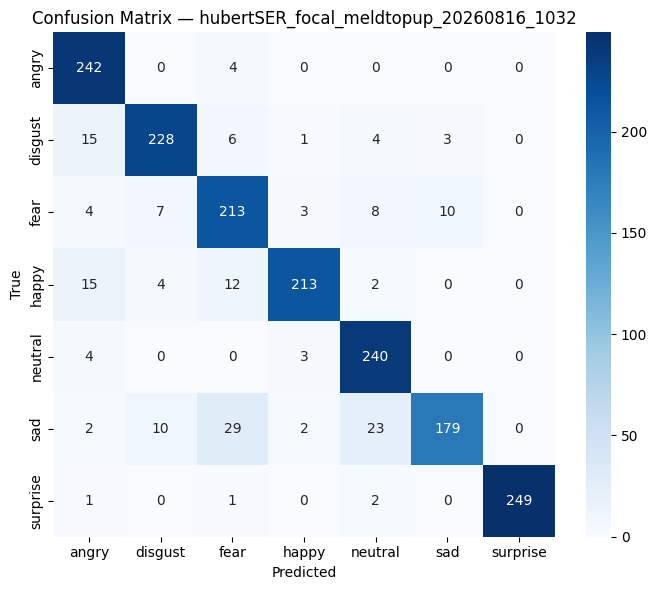

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=EMOTIONS, yticklabels=EMOTIONS, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {RUN_NAME}")
plt.tight_layout()
plt.show()

## 13. Save the fine-tuned model (uniquely named)

Saved under a folder named after this run (`RUN_NAME`) both locally and, optionally, in Drive — so it sits alongside past experiments without overwriting or confusing them.


In [29]:
SAVE_DIR = "/content/drive/MyDrive/MindSight_Models/audio_model"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
feature_extractor.save_pretrained(SAVE_DIR)
print(f"Model saved to {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/MindSight_Models/audio_model


## 14. Chatbot-style inference: audio in → predicted emotion out

Takes a raw audio file (uploaded, recorded, or streamed from the user), preprocesses it exactly like training data, and returns the predicted emotion plus confidence scores across all 7 classes.


In [30]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving angry_1.ogg to angry_1.ogg
Detected emotion: angry  (confidence: 65.7%)
Full distribution: {'angry': 0.6572, 'disgust': 0.3219, 'fear': 0.0002, 'happy': 0.0043, 'neutral': 0.0047, 'sad': 0.0014, 'surprise': 0.0102}
Bot: I can hear you're frustrated — let's sort this out together.


('angry',
 {'angry': 0.6572,
  'disgust': 0.3219,
  'fear': 0.0002,
  'happy': 0.0043,
  'neutral': 0.0047,
  'sad': 0.0014,
  'surprise': 0.0102})

In [31]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving fear_3.ogg to fear_3.ogg
Detected emotion: happy  (confidence: 59.9%)
Full distribution: {'angry': 0.0006, 'disgust': 0.0013, 'fear': 0.2939, 'happy': 0.5988, 'neutral': 0.0004, 'sad': 0.0128, 'surprise': 0.0923}
Bot: You sound great! Glad to hear it 😊


('happy',
 {'angry': 0.0006,
  'disgust': 0.0013,
  'fear': 0.2939,
  'happy': 0.5988,
  'neutral': 0.0004,
  'sad': 0.0128,
  'surprise': 0.0923})

In [32]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving disgust_2.ogg to disgust_2.ogg
Detected emotion: happy  (confidence: 85.9%)
Full distribution: {'angry': 0.0011, 'disgust': 0.0086, 'fear': 0.0103, 'happy': 0.8589, 'neutral': 0.0, 'sad': 0.001, 'surprise': 0.1201}
Bot: You sound great! Glad to hear it 😊


('happy',
 {'angry': 0.0011,
  'disgust': 0.0086,
  'fear': 0.0103,
  'happy': 0.8589,
  'neutral': 0.0,
  'sad': 0.001,
  'surprise': 0.1201})

In [33]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving happy_4.ogg to happy_4.ogg
Detected emotion: happy  (confidence: 97.0%)
Full distribution: {'angry': 0.0001, 'disgust': 0.0001, 'fear': 0.0, 'happy': 0.9699, 'neutral': 0.0, 'sad': 0.0, 'surprise': 0.03}
Bot: You sound great! Glad to hear it 😊


('happy',
 {'angry': 0.0001,
  'disgust': 0.0001,
  'fear': 0.0,
  'happy': 0.9699,
  'neutral': 0.0,
  'sad': 0.0,
  'surprise': 0.03})

In [34]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving neutral_9.ogg to neutral_9.ogg
Detected emotion: sad  (confidence: 52.4%)
Full distribution: {'angry': 0.0001, 'disgust': 0.0262, 'fear': 0.0166, 'happy': 0.0014, 'neutral': 0.3157, 'sad': 0.524, 'surprise': 0.1159}
Bot: I'm sorry you're feeling down. I'm here if you want to talk.


('sad',
 {'angry': 0.0001,
  'disgust': 0.0262,
  'fear': 0.0166,
  'happy': 0.0014,
  'neutral': 0.3157,
  'sad': 0.524,
  'surprise': 0.1159})

In [35]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving sad_6.ogg to sad_6.ogg
Detected emotion: neutral  (confidence: 85.1%)
Full distribution: {'angry': 0.0, 'disgust': 0.0004, 'fear': 0.0055, 'happy': 0.0003, 'neutral': 0.8507, 'sad': 0.1431, 'surprise': 0.0001}
Bot: Got it, how can I help you today?


('neutral',
 {'angry': 0.0,
  'disgust': 0.0004,
  'fear': 0.0055,
  'happy': 0.0003,
  'neutral': 0.8507,
  'sad': 0.1431,
  'surprise': 0.0001})

In [36]:
import torch.nn.functional as F

inf_feature_extractor = AutoFeatureExtractor.from_pretrained(SAVE_DIR)
inf_model = AutoModelForAudioClassification.from_pretrained(SAVE_DIR).to(device)
inf_model.eval()

def predict_emotion(audio_path, max_duration=MAX_DURATION):
    """Chatbot-facing function: audio file path -> predicted emotion + probabilities."""
    speech, sr = librosa.load(audio_path, sr=TARGET_SR)

    inputs = inf_feature_extractor(
        speech,
        sampling_rate=TARGET_SR,
        max_length=int(TARGET_SR * max_duration),
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    input_values = inputs["input_values"].to(device)

    with torch.no_grad():
        logits = inf_model(input_values).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    predicted_emotion = id2label[pred_id]
    prob_dict = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return predicted_emotion, prob_dict


def chatbot_respond_to_audio(audio_path):
    """Example of how a chatbot would use the prediction to shape its reply."""
    emotion, probs = predict_emotion(audio_path)

    responses = {
        "angry":    "I can hear you're frustrated — let's sort this out together.",
        "disgust":  "That sounds unpleasant, I understand your reaction.",
        "fear":     "It's okay to feel anxious — I'm here to help, take your time.",
        "happy":    "You sound great! Glad to hear it 😊",
        "neutral":  "Got it, how can I help you today?",
        "sad":      "I'm sorry you're feeling down. I'm here if you want to talk.",
        "surprise": "Oh, that caught you off guard! Tell me more.",
    }

    print(f"Detected emotion: {emotion}  (confidence: {probs[emotion]*100:.1f}%)")
    print("Full distribution:", probs)
    print("Bot:", responses[emotion])
    return emotion, probs


# --- Try it out ---
from google.colab import files
uploaded_audio = files.upload()
test_audio_path = list(uploaded_audio.keys())[0]
chatbot_respond_to_audio(test_audio_path)


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Saving surprise_5.ogg to surprise_5.ogg
Detected emotion: happy  (confidence: 89.3%)
Full distribution: {'angry': 0.0069, 'disgust': 0.0031, 'fear': 0.0292, 'happy': 0.8934, 'neutral': 0.0073, 'sad': 0.0241, 'surprise': 0.036}
Bot: You sound great! Glad to hear it 😊


('happy',
 {'angry': 0.0069,
  'disgust': 0.0031,
  'fear': 0.0292,
  'happy': 0.8934,
  'neutral': 0.0073,
  'sad': 0.0241,
  'surprise': 0.036})

In [37]:
import shutil, os

backup_path = "/content/audio_model_local_backup"
shutil.move("/content/drive", backup_path)
print("Moved local fake-drive folder to:", backup_path)

Moved local fake-drive folder to: /content/audio_model_local_backup


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
real_target = "/content/drive/MyDrive/MindSight_Models/audio_model"
os.makedirs(os.path.dirname(real_target), exist_ok=True)
shutil.copytree(f"{backup_path}/MyDrive/MindSight_Models/audio_model", real_target)
print("Copied to real Drive at:", real_target)

Copied to real Drive at: /content/drive/MyDrive/MindSight_Models/audio_model


In [40]:
!ls "/content/drive/MyDrive/MindSight_Models/audio_model"

config.json  model.safetensors	preprocessor_config.json
